In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [2]:
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")
print(path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
/kaggle/input/ames-housing-dataset


In [3]:
df =pd.read_csv(f"{path}/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.shape

(2930, 82)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
df['SalePrice'].describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


In [7]:
df['MS SubClass'] = df['MS SubClass'].astype(str)

In [8]:
top_null_cols = df.isnull().sum().sort_values(ascending= False).head(20)
top_null_cols

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Yr Blt,159
Garage Cond,159


In [9]:
for value in top_null_cols.index:
    print(f"{value} --- {df[value].dtype}")

Pool QC --- object
Misc Feature --- object
Alley --- object
Fence --- object
Mas Vnr Type --- object
Fireplace Qu --- object
Lot Frontage --- float64
Garage Qual --- object
Garage Yr Blt --- float64
Garage Cond --- object
Garage Finish --- object
Garage Type --- object
Bsmt Exposure --- object
BsmtFin Type 2 --- object
Bsmt Qual --- object
Bsmt Cond --- object
BsmtFin Type 1 --- object
Mas Vnr Area --- float64
Bsmt Full Bath --- float64
Bsmt Half Bath --- float64


In [10]:
# Segregation Numerical and Categorical columns

categorical_cols = df.select_dtypes(include = 'object').columns
numerical_cols = df.select_dtypes(include = ['float64','int64']).columns

In [11]:
print("Categorical columns with null values:")

df[categorical_cols].isnull().sum()[df[categorical_cols].isnull().sum() > 0]

Categorical columns with null values:


,0
Alley,2732
Mas Vnr Type,1775
Bsmt Qual,80
Bsmt Cond,80
Bsmt Exposure,83
BsmtFin Type 1,80
BsmtFin Type 2,81
Electrical,1
Fireplace Qu,1422
Garage Type,157


In [12]:
# all the categorical feature having NaN values , didn't have that feature so filling with None
for col in categorical_cols:
  df[f"{col}"] = df[f"{col}"].fillna('None')

In [13]:
# cross-checking
df[categorical_cols].isnull().sum()[df[categorical_cols].isnull().sum() > 0]

,0


In [14]:
print("Numerical columns with null values:")

df[numerical_cols].isnull().sum()[df[numerical_cols].isnull().sum() > 0]

Numerical columns with null values:


,0
Lot Frontage,490
Mas Vnr Area,23
BsmtFin SF 1,1
BsmtFin SF 2,1
Bsmt Unf SF,1
Total Bsmt SF,1
Bsmt Full Bath,2
Bsmt Half Bath,2
Garage Yr Blt,159
Garage Cars,1


In [15]:
small_null_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF',
                   'Bsmt Full Bath', 'Bsmt Half Bath','Garage Cars', 'Garage Area']

df[small_null_cols] = df[small_null_cols].fillna(0)

In [16]:
#checking the numerical cols with null values that either the feature is absent or just data is not recorded
df[df['Garage Yr Blt'].isnull()][['Garage Type']].value_counts()

,count
Garage Type,
None,157
Detchd,2


In [17]:
df[df['Mas Vnr Area'].isnull()][['Mas Vnr Type']].value_counts()

,count
Mas Vnr Type,
None,23


In [18]:
 # filling the na data with 0 as they have not this feature
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [19]:
mask = (df['Garage Type'] != 'None') & (df['Garage Yr Blt'].isnull()) #garage type exists but  the garage year built shows misssing value

df.loc[mask, 'Garage Yr Blt'] = df.loc[mask, 'Year Built'] # filling those rows having na data of garage year built with the house built year

df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0) # filling those which has no garage hence no garage year built
df['Garage Yr Blt'].isnull().sum()

np.int64(0)

<Axes: >

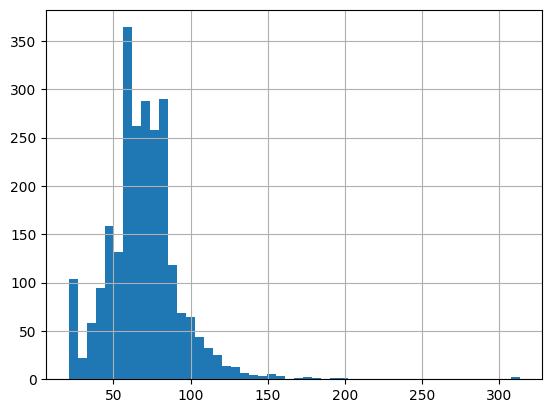

In [20]:
df['Lot Frontage'].hist(bins=50)

In [21]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [22]:
df['Garage Yr Blt'].isnull().sum()

np.int64(0)

In [23]:
#checing if there's any still null values
df.isnull().sum().sum()

np.int64(0)

In [24]:
print(type(numerical_cols))

<class 'pandas.core.indexes.base.Index'>


In [25]:
numerical_cols = df.select_dtypes(include = ['float64','int64'])


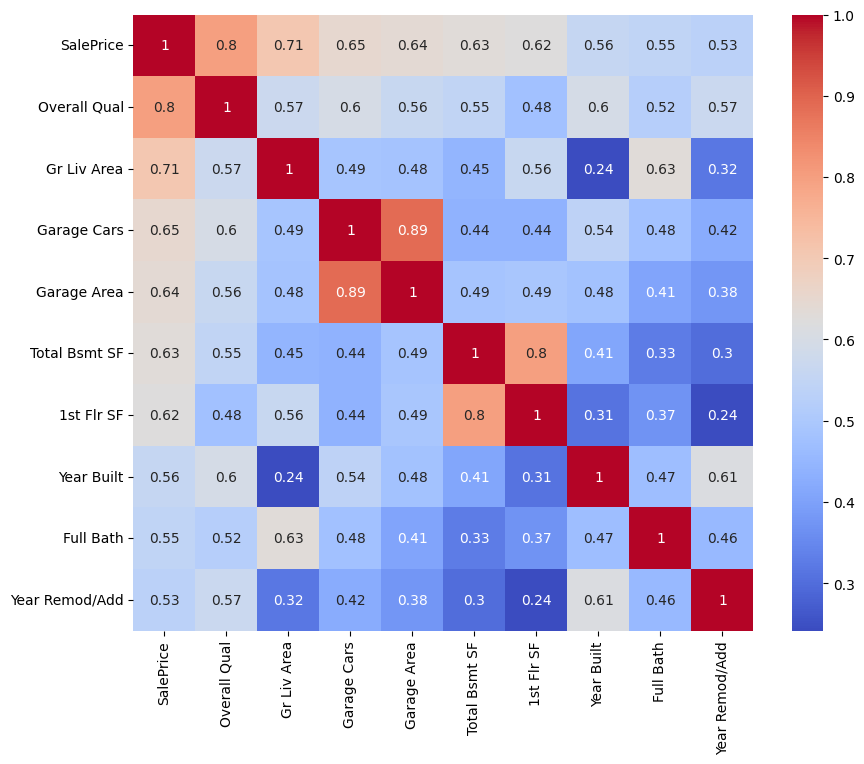

In [26]:
# finding out the corelation of feature with sale price

corr_numeric = numerical_cols.corr()['SalePrice'].sort_values(ascending = False)

plt.figure(figsize=(10,8))
top_corr_numeric_features = corr_numeric.head(10).index
sns.heatmap(numerical_cols[top_corr_numeric_features].corr(), annot=True, cmap='coolwarm')
plt.show()


In [27]:
df['Gr Liv Area']

,Gr Liv Area
0,1656
1,896
2,1329
3,2110
4,1629
...,...
2925,1003
2926,902
2927,970
2928,1389


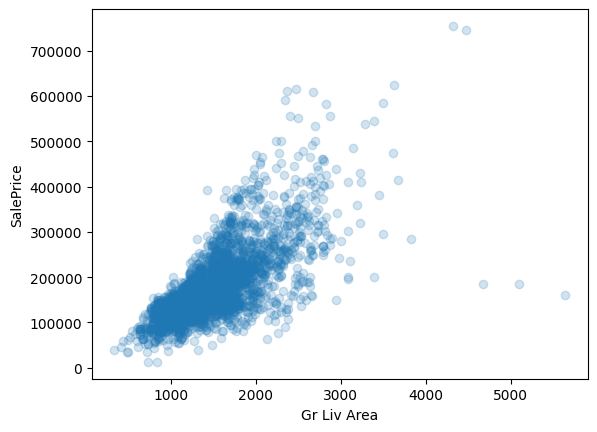

In [28]:
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha = 0.2)
plt.xlabel('Gr Liv Area')
plt.ylabel('SalePrice')
plt.show()

/tmp/ipykernel_1398/4287304171.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_by_area = df['SalePrice'].groupby(Grlivarea_bin).mean()


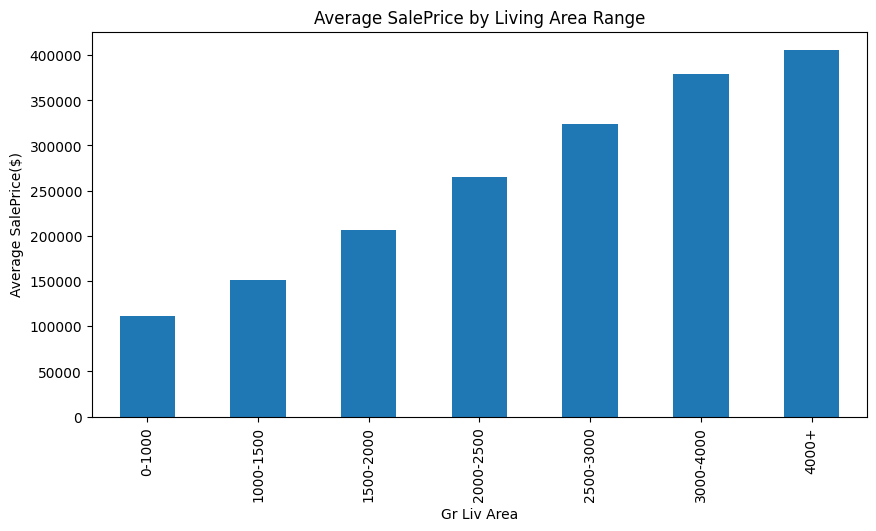

In [29]:
bin=[0, 1000, 1500, 2000, 2500, 3000, 4000, 6000]
label=['0-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-4000', '4000+']
Grlivarea_bin = pd.cut(df['Gr Liv Area'], bins=bin,labels=label)

avg_price_by_area = df['SalePrice'].groupby(Grlivarea_bin).mean()

avg_price_by_area.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average SalePrice($)")
plt.title("Average SalePrice by Living Area Range")
plt.show()

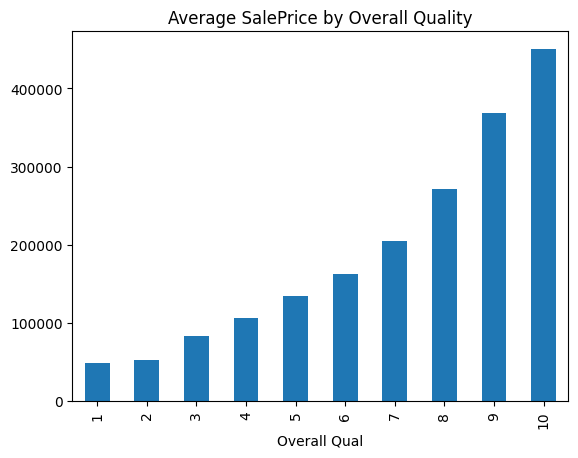

In [30]:
df.groupby('Overall Qual')['SalePrice'].mean().plot(kind='bar')
plt.title("Average SalePrice by Overall Quality")
plt.show()

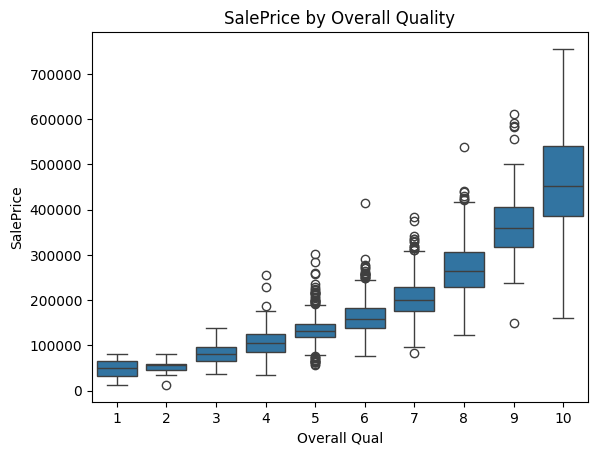

In [31]:
sns.boxplot(x=df['Overall Qual'], y=df['SalePrice'])
plt.title("SalePrice by Overall Quality")
plt.show()

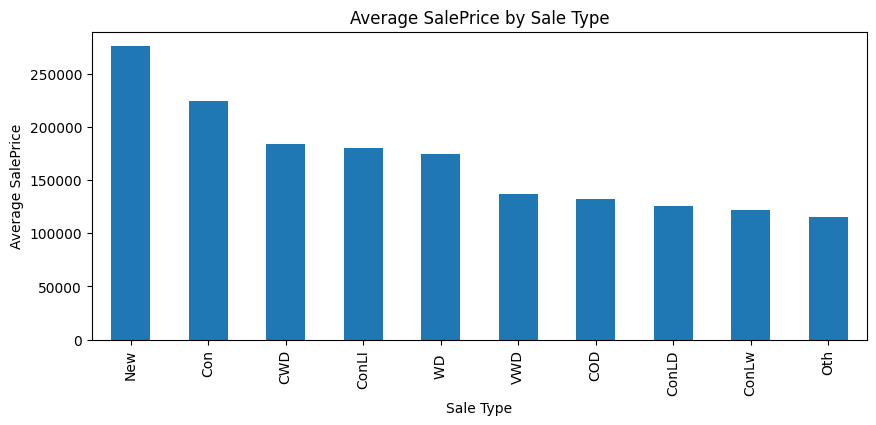

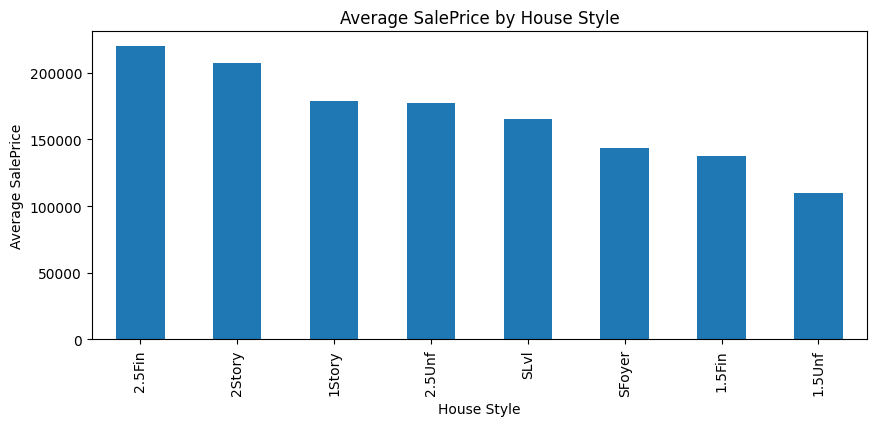

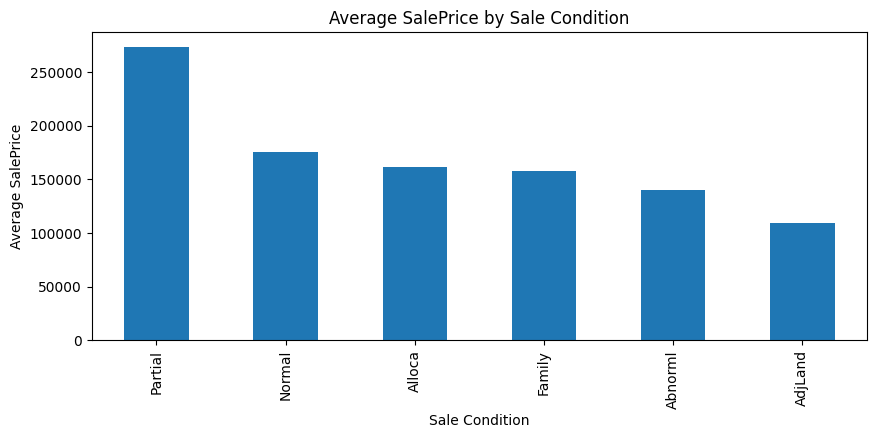

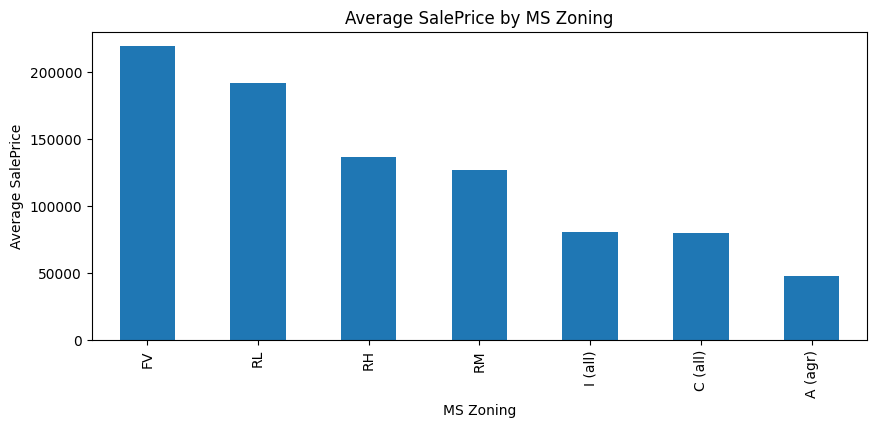

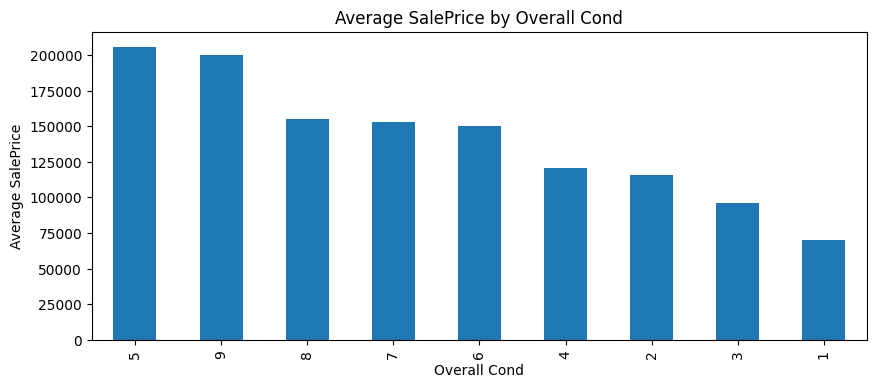

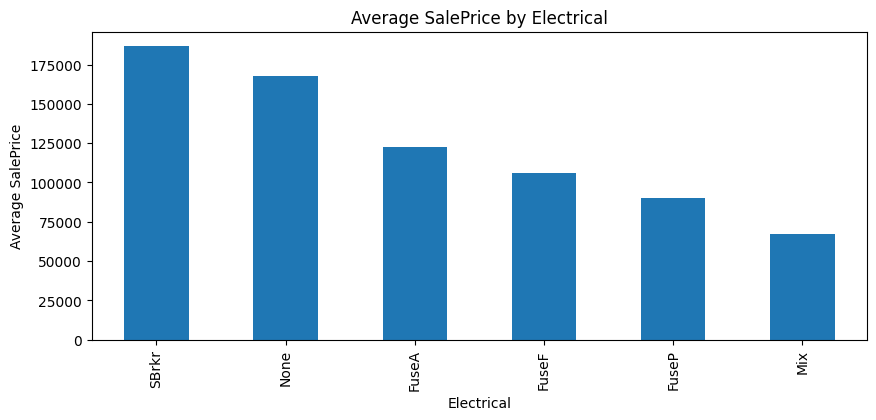

In [32]:
for col in ['Sale Type','House Style', 'Sale Condition' , 'MS Zoning','Overall Cond','Electrical']:
    plt.figure(figsize=(10,4))
    df.groupby(col)['SalePrice'].mean().sort_values(ascending=False).plot(kind='bar')
    plt.title(f"Average SalePrice by {col}")
    plt.ylabel("Average SalePrice")
    plt.show()

In [33]:
df.shape

(2930, 82)

In [34]:
df = df.drop(columns=['Order', 'PID'], errors='ignore')

In [35]:
df['Target'] = df['SalePrice']
df = df.drop(columns=['SalePrice'])

In [36]:
df.shape

(2930, 80)

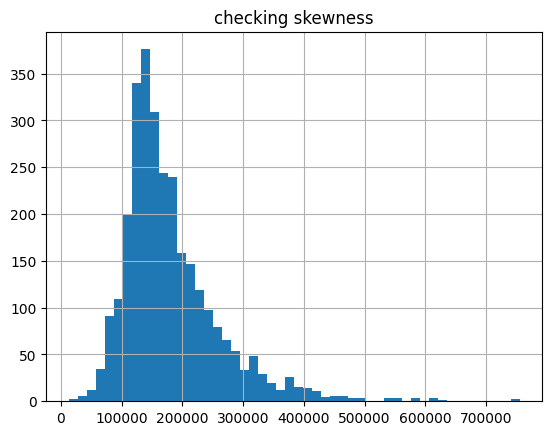

In [37]:
df['Target'].hist(bins=50)
plt.title("checking skewness")
plt.show()

In [38]:
df['Target'] = np.log1p(df['Target'])


In [39]:
df = pd.get_dummies(df, columns= categorical_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [40]:
df.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,0,0,0,0,1,0,0,0,1,0
1,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0,0,0,0,1,0,0,0,1,0
2,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,0,0,0,0,1,0,0,0,1,0
3,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,0,0,0,0,1,0,0,0,1,0
4,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,0,0,0,0,1,0,0,0,1,0


In [41]:
X = df.drop(columns=['Target'])
y = df['Target']

In [42]:
X.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,0,0,0,0,1,0,0,0,1,0
1,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0,0,0,0,1,0,0,0,1,0
2,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,0,0,0,0,1,0,0,0,1,0
3,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,0,0,0,0,1,0,0,0,1,0
4,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,0,0,0,0,1,0,0,0,1,0


In [43]:
y.head()

,Target
0,12.278398
1,11.561725
2,12.055256
3,12.404928
4,12.154258


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [47]:
from sklearn.linear_model import LinearRegression
lg = LinearRegression()
lg.fit(X_train, y_train)

LinearRegression()

In [48]:
y_test_pred = lg.predict(X_test)
y_train_pred = lg.predict(X_train)

In [49]:
r2_score(y_train,y_train_pred)

0.9403390831887719

In [50]:
r2_score(y_test, y_test_pred)

0.796782810789076

In [51]:
sgd = SGDRegressor(
    penalty='l2',
    alpha=1e-4,
    learning_rate='invscaling',
    eta0=1e-4,
    power_t=0.25,
    max_iter=5000,
    random_state=42
)
sgd.fit(X_train, y_train)

y_train_pred = sgd.predict(X_train)
y_test_pred = sgd.predict(X_test)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

Train R2: 0.8862858123327247
Test R2: 0.8952446648971307


In [52]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)
print("Best Ridge alpha:", ridge.alpha_)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=5000)
lasso.fit(X_train, y_train)
print("Best Lasso alpha:", lasso.alpha_)

elastic = ElasticNetCV(alphas=alphas, l1_ratio=[.1, .5, .7, .9, .95, 1], cv=5, max_iter=5000)
elastic.fit(X_train, y_train)
print("Best ElasticNet alpha:", elastic.alpha_, "l1_ratio:", elastic.l1_ratio_)

Best Ridge alpha: 100.0
Best Lasso alpha: 0.01
Best ElasticNet alpha: 0.01 l1_ratio: 0.5


In [57]:
models = {
    "SGD Regressor": sgd,
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic,
}

results = []
for name, model in models.items():
    if name in ["Linear Regression", "SGD Regressor"]:
        model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Train R2": r2_score(y_train, y_train_pred),
        "Train MSE " : mean_squared_error(y_train , y_train_pred),

        "Test MSE": mean_squared_error(y_test, y_test_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test R2": r2_score(y_test, y_test_pred),
    })

results_df = pd.DataFrame(results)
print(results_df)

           Model  Train MAE  Train RMSE  Train R2  Train MSE   Test MSE  \
0  SGD Regressor   0.226464    0.337215  0.886286    0.113714  0.098392   
1          Ridge   0.175051    0.262427  0.931132    0.068868  0.108346   
2          Lasso   0.193187    0.291360  0.915109    0.084891  0.104819   
3     ElasticNet   0.184984    0.278313  0.922542    0.077458  0.107047   

   Test MAE  Test RMSE   Test R2  
0  0.231315   0.313675  0.895245  
1  0.215712   0.329160  0.884647  
2  0.211783   0.323758  0.888402  
3  0.210447   0.327181  0.886030  
